# Airavata Terminology Register Fine-tuning

Kaggle-ready notebook for Hindi MT terminology post-editing using the project contract:

`[SRC]` source sentence, `[TRL]` base MT output, `[TERMS]` runtime terminology map, `[OUT]` corrected Hindi output.

This version trains on `train_data.jsonl`, creates a stratified validation split from train only, evaluates on a separate `test_data.jsonl`, and runs training plus generation across two Kaggle T4 GPUs with `accelerate`.

In [1]:
# Cell 1: Install dependencies
# Run this cell first on Kaggle, then restart the kernel once if pip upgrades core packages.

!pip install -q --upgrade \
    "numpy==2.0.2" \
    "scipy>=1.13.0" \
    "transformers>=4.45.0" \
    "peft>=0.13.0" \
    "trl>=0.12.0" \
    "bitsandbytes>=0.44.0" \
    "datasets>=3.0.0" \
    "accelerate>=1.0.0" \
    sentencepiece \
    sacrebleu \
    matplotlib \
    pandas

print("✓ Install complete. If Kaggle asks, restart the kernel and continue from Cell 2.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Cell 2: Imports, Hugging Face login, GPU check
import os, json, re, random, math, subprocess, platform, glob, shutil, textwrap
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Any

import torch
import pandas as pd
from datasets import Dataset
from huggingface_hub import login

# Prefer Kaggle Secret named HF_TOKEN. Fallback to environment variable.
# If neither exists, paste the token into a hidden runtime prompt.
# Do not hard-code live tokens in notebooks you share or commit.
def get_hf_token():
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")
    if token:
        return token
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        pass
    try:
        from getpass import getpass
        pasted = getpass("Paste Hugging Face token, then press Enter: ").strip()
        return pasted or None
    except Exception:
        return None

HF_TOKEN = get_hf_token()
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    login(token=HF_TOKEN)
    print("✓ Logged in to Hugging Face Hub")
else:
    print("⚠ No HF token found. Add a Kaggle secret named HF_TOKEN if the model requires authentication.")

n_gpu = torch.cuda.device_count()
print(f"Python  : {platform.python_version()}")
print(f"PyTorch : {torch.__version__}")
print(f"GPUs    : {n_gpu}")
for i in range(n_gpu):
    g = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {g.name} | VRAM={g.total_memory/1e9:.1f} GB")

if n_gpu == 0:
    raise RuntimeError("No GPU found. Enable GPU in Kaggle notebook settings.")

NUM_PROCESSES = min(2, n_gpu)
print(f"✓ accelerate processes: {NUM_PROCESSES}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in to Hugging Face Hub
Python  : 3.12.12
PyTorch : 2.10.0+cu128
GPUs    : 2
  GPU 0: Tesla T4 | VRAM=15.6 GB
  GPU 1: Tesla T4 | VRAM=15.6 GB
✓ accelerate processes: 2


In [3]:
# Cell 3: Configuration
MODEL_ID = "ai4bharat/Airavata"
LANGUAGE = "hi"

OUTPUT_DIR = "/kaggle/working/airavata_register"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
SPLIT_DIR = f"{OUTPUT_DIR}/splits"
PRED_DIR = f"{OUTPUT_DIR}/predictions"

MAX_SEQ_LEN = 512
VAL_RATIO = 0.10
SEED = 42

EPOCHS = 4
BATCH_SIZE = 4            # per GPU
EVAL_BATCH_SIZE = 4       # per GPU
GRAD_ACCUM = 4            # effective train batch = BATCH_SIZE * GRAD_ACCUM * NUM_PROCESSES
LR = 2e-4
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.01

LOAD_IN_4BIT = True
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

SRC_TOKEN = "[SRC]"
TRL_TOKEN = "[TRL]"
TERMS_TOKEN = "[TERMS]"
OUT_TOKEN = "[OUT]"
SPECIAL_TOKENS = [SRC_TOKEN, TRL_TOKEN, TERMS_TOKEN, OUT_TOKEN]
REGISTERS = ["modern", "traditional"]

for p in [OUTPUT_DIR, CHECKPOINT_DIR, SPLIT_DIR, PRED_DIR]:
    os.makedirs(p, exist_ok=True)

print("✓ Configuration ready")
print(f"Model: {MODEL_ID}")
print(f"Output: {OUTPUT_DIR}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM * NUM_PROCESSES}")

✓ Configuration ready
Model: ai4bharat/Airavata
Output: /kaggle/working/airavata_register
Effective batch size: 32


In [4]:
# Cell 4: Locate train_data.jsonl and test_data.jsonl in Kaggle input
# Expected upload layout from your Kaggle dataset:
# /kaggle/input/datasets/vpnydv123/process9data/train_data.jsonl
# /kaggle/input/datasets/vpnydv123/process9data/test_data.jsonl
# The finder also handles one nested folder level or local notebook testing.

def find_data_file(filename: str) -> str:
    candidates = [
        Path("/kaggle/input/datasets/vpnydv123/process9dataa") / filename,
        Path("/kaggle/input/dataset") / filename,
        Path("/kaggle/input/dataset/dataset") / filename,
        Path("/kaggle/input") / filename,
        Path(".") / filename,
    ]
    for c in candidates:
        if c.exists():
            return str(c)
    for root in [Path("/kaggle/input"), Path(".")]:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return str(matches[0])
    raise FileNotFoundError(f"Could not find {filename}. Upload it in a Kaggle dataset folder named dataset.")

TRAIN_DATA_PATH = find_data_file("new_train_data.jsonl")
TEST_DATA_PATH = find_data_file("new_test_data.jsonl")
print(f"train_data: {TRAIN_DATA_PATH}")
print(f"test_data : {TEST_DATA_PATH}")

train_data: /kaggle/input/datasets/vpnydv123/process9dataa/train_data.jsonl
test_data : /kaggle/input/datasets/vpnydv123/process9dataa/test_data.jsonl


In [5]:
# Cell 5: Load and validate data
REQUIRED_FIELDS = ["source", "base_translation", "terminology_map", "corrected_output", "register"]
OPTIONAL_FIELDS = ["instruction", "challenge_type"]

def read_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                row = json.loads(line)
            except json.JSONDecodeError as e:
                raise ValueError(f"Invalid JSON in {path}:{line_no}: {e}")
            rows.append(row)
    return rows

def validate_rows(rows: List[Dict[str, Any]], name: str):
    if not rows:
        raise ValueError(f"{name} is empty")
    missing_report = Counter()
    for row in rows:
        for field in REQUIRED_FIELDS:
            if field not in row or row[field] in [None, ""]:
                missing_report[field] += 1
    if missing_report:
        raise ValueError(f"{name} has missing required fields: {dict(missing_report)}")
    print(f"✓ {name}: {len(rows)} rows")
    print(f"  fields: {sorted(rows[0].keys())}")
    print(f"  registers: {dict(Counter(r.get('register', 'unknown') for r in rows))}")
    print(f"  challenges: {dict(sorted(Counter(r.get('challenge_type', 'unknown') for r in rows).items()))}")

train_all_raw = read_jsonl(TRAIN_DATA_PATH)
test_raw = read_jsonl(TEST_DATA_PATH)
validate_rows(train_all_raw, "train_data")
validate_rows(test_raw, "test_data")

✓ train_data: 1000 rows
  fields: ['base_translation', 'challenge_type', 'corrected_output', 'instruction', 'register', 'source', 'terminology_map']
  registers: {'modern': 696, 'traditional': 170, 'business': 134}
  challenges: {'3.1': 380, '3.2': 87, '3.3': 159, '3.4': 76, '3.5': 167, '3.6': 84, '3.7': 47}
✓ test_data: 250 rows
  fields: ['base_translation', 'challenge_type', 'corrected_output', 'instruction', 'register', 'source', 'terminology_map']
  registers: {'modern': 169, 'business': 37, 'traditional': 44}
  challenges: {'3.1': 85, '3.2': 28, '3.3': 33, '3.4': 18, '3.5': 46, '3.6': 20, '3.7': 20}


In [6]:
# Cell 6: Stratified validation split from train_data only
# Goal: validation should include different registers, challenge types, single/multi-term rows,
# and single/multi-sentence examples whenever the training data contains enough examples.

TERM_SPLIT_RE = re.compile(r"\s*(?:,|;|।)\s*")
SENTENCE_END_RE = re.compile(r"[.!?।]+")

def count_terms(terminology_map: str) -> int:
    parts = [p.strip() for p in TERM_SPLIT_RE.split(str(terminology_map)) if p.strip()]
    return max(1, len(parts))

def count_sentences(row: Dict[str, Any]) -> int:
    counts = []
    for key in ["source", "base_translation", "corrected_output"]:
        text = str(row.get(key, ""))
        counts.append(len([x for x in SENTENCE_END_RE.split(text) if x.strip()]))
    return max(1, max(counts) if counts else 1)

def row_signature(row: Dict[str, Any]) -> Tuple[str, str, str, str]:
    term_n = count_terms(row.get("terminology_map", ""))
    sent_n = count_sentences(row)
    return (
        str(row.get("register", "unknown")),
        str(row.get("challenge_type", "unknown")),
        "multi_term" if term_n >= 2 else "single_term",
        "multi_sentence" if sent_n >= 2 else "single_sentence",
    )

def add_metadata(rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    out = []
    for i, row in enumerate(rows):
        r = dict(row)
        r["row_id"] = i
        r["term_count"] = count_terms(r.get("terminology_map", ""))
        r["sentence_count"] = count_sentences(r)
        sig = row_signature(r)
        r["stratify_signature"] = "|".join(sig)
        out.append(r)
    return out

def stratified_validation_split(rows: List[Dict[str, Any]], val_ratio: float, seed: int):
    rng = random.Random(seed)
    rows = add_metadata(rows)
    groups = defaultdict(list)
    for row in rows:
        groups[row["stratify_signature"]].append(row)
    
    train, val, singleton_groups = [], [], []
    for sig, group in sorted(groups.items()):
        rng.shuffle(group)
        if len(group) == 1:
            train.extend(group)
            singleton_groups.append(sig)
            continue
        n_val = max(1, int(round(len(group) * val_ratio)))
        n_val = min(n_val, len(group) - 1)
        val.extend(group[:n_val])
        train.extend(group[n_val:])
    
    rng.shuffle(train)
    rng.shuffle(val)
    return train, val, singleton_groups

train_raw, val_raw, singleton_groups = stratified_validation_split(train_all_raw, VAL_RATIO, SEED)

def coverage_table(rows: List[Dict[str, Any]], name: str) -> pd.DataFrame:
    records = []
    for key, label_fn in [
        ("register", lambda r: r.get("register", "unknown")),
        ("challenge_type", lambda r: r.get("challenge_type", "unknown")),
        ("term_bucket", lambda r: "multi_term" if r.get("term_count", count_terms(r.get("terminology_map", ""))) >= 2 else "single_term"),
        ("sentence_bucket", lambda r: "multi_sentence" if r.get("sentence_count", count_sentences(r)) >= 2 else "single_sentence"),
    ]:
        counts = Counter(label_fn(r) for r in rows)
        for value, n in sorted(counts.items()):
            records.append({"split": name, "type": key, "value": value, "count": n})
    return pd.DataFrame(records)

print("Split summary")
print(f"  train: {len(train_raw)}")
print(f"  val  : {len(val_raw)}")
print(f"  test : {len(test_raw)}")
if singleton_groups:
    print(f"  note : {len(singleton_groups)} rare composite groups had only one row, so they stayed in train to avoid leakage.")

display(pd.concat([coverage_table(train_raw, "train"), coverage_table(val_raw, "val"), coverage_table(add_metadata(test_raw), "test")], ignore_index=True))

# Persist raw splits for reproducibility and subprocess inference.
def write_jsonl(path: str, rows: List[Dict[str, Any]]):
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

write_jsonl(f"{SPLIT_DIR}/train.jsonl", train_raw)
write_jsonl(f"{SPLIT_DIR}/val.jsonl", val_raw)
write_jsonl(f"{SPLIT_DIR}/test.jsonl", add_metadata(test_raw))
print(f"✓ Saved split JSONL files to {SPLIT_DIR}")

Split summary
  train: 898
  val  : 102
  test : 250
  note : 6 rare composite groups had only one row, so they stayed in train to avoid leakage.


,split,type,value,count
0,train,register,business,118
1,train,register,modern,628
2,train,register,traditional,152
3,train,challenge_type,3.1,342
4,train,challenge_type,3.2,78
5,train,challenge_type,3.3,143
6,train,challenge_type,3.4,67
7,train,challenge_type,3.5,150
8,train,challenge_type,3.6,76
9,train,challenge_type,3.7,42


✓ Saved split JSONL files to /kaggle/working/airavata_register/splits


In [7]:
# Cell 7: Prompt formatting and tokenizer
from transformers import AutoTokenizer

SYSTEM_INSTRUCTION = "You are a Hindi linguistic post-editor. Correct the base translation by applying the terminology map and fixing any resulting grammatical errors."

def build_prompt(row: Dict[str, Any], include_output: bool = True) -> str:
    lines = []
    # Keep the project-required four-field contract. Source is optional but included when present.
    if str(row.get("source", "")).strip():
        lines.append(f"{SRC_TOKEN} {str(row['source']).strip()}")
    lines.append(f"{TRL_TOKEN} {str(row['base_translation']).strip()}")
    lines.append(f"{TERMS_TOKEN} {str(row.get('terminology_map', '')).strip()}")
    if include_output:
        lines.append(f"{OUT_TOKEN} {str(row['corrected_output']).strip()}")
    else:
        lines.append(OUT_TOKEN)
    return "\n".join(lines)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True, token=HF_TOKEN)
new_tokens = [tok for tok in SPECIAL_TOKENS if tok not in tokenizer.get_vocab()]
if new_tokens:
    tokenizer.add_special_tokens({"additional_special_tokens": new_tokens})
    print(f"Added special tokens: {new_tokens}")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token or tokenizer.unk_token
tokenizer.padding_side = "right"

def make_text_row(row: Dict[str, Any]) -> Dict[str, Any]:
    return {
        "text": build_prompt(row, include_output=True) + tokenizer.eos_token,
        "register": row.get("register", "unknown"),
        "challenge_type": row.get("challenge_type", "unknown"),
        "term_count": row.get("term_count", count_terms(row.get("terminology_map", ""))),
        "sentence_count": row.get("sentence_count", count_sentences(row)),
    }

train_hf = Dataset.from_list([make_text_row(r) for r in train_raw])
val_hf = Dataset.from_list([make_text_row(r) for r in val_raw])

lengths = [len(tokenizer(x["text"]).input_ids) for x in train_hf]
lengths_sorted = sorted(lengths)
over = sum(l > MAX_SEQ_LEN for l in lengths)
print(f"Tokenizer vocab size: {len(tokenizer)}")
print(f"Train lengths: min={lengths_sorted[0]}, median={lengths_sorted[len(lengths_sorted)//2]}, max={lengths_sorted[-1]}")
print(f"Rows over MAX_SEQ_LEN={MAX_SEQ_LEN}: {over}")

train_hf.save_to_disk(f"{OUTPUT_DIR}/train_hf")
val_hf.save_to_disk(f"{OUTPUT_DIR}/val_hf")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/tokenizer")

print("\nSample training prompt")
print("-" * 80)
print(train_hf[0]["text"][:1200])
print("-" * 80)
print("✓ Datasets and tokenizer saved for training subprocess")

config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/968k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Added special tokens: ['[SRC]', '[TRL]', '[TERMS]', '[OUT]']
Tokenizer vocab size: 48069
Train lengths: min=33, median=66, max=182
Rows over MAX_SEQ_LEN=384: 0


Saving the dataset (0/1 shards):   0%|          | 0/898 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/102 [00:00<?, ? examples/s]


Sample training prompt
--------------------------------------------------------------------------------
[SRC] Send an alert to Priya's salary accounts.
[TRL] Priya के वेतन खातों को अलर्ट भेजें।
[TERMS] Accounts → अकाउंट्स
[OUT] Priya के वेतन अकाउंट्स को अलर्ट भेजें।</s>
--------------------------------------------------------------------------------
✓ Datasets and tokenizer saved for training subprocess


In [8]:
%%writefile /kaggle/working/train_airavata.py
# Cell 8: Write multi-GPU QLoRA training script

import os, json, torch
from dataclasses import dataclass
from typing import List, Dict, Any

from huggingface_hub import login
from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

MODEL_ID = "ai4bharat/Airavata"
OUTPUT_DIR = "/kaggle/working/airavata_register"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
MAX_SEQ_LEN = 512
EPOCHS = 4
BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRAD_ACCUM = 4
LR = 2e-4
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.01
SEED = 42
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
PREFERRED_LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
OUT_TOKEN = "[OUT]"

hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")
if hf_token:
    login(token=hf_token)

set_seed(SEED)
local_rank = int(os.environ.get("LOCAL_RANK", "0"))
rank = int(os.environ.get("RANK", "0"))
compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

tokenizer = AutoTokenizer.from_pretrained(f"{OUTPUT_DIR}/tokenizer", trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token or tokenizer.unk_token

train_hf = load_from_disk(f"{OUTPUT_DIR}/train_hf")
val_hf = load_from_disk(f"{OUTPUT_DIR}/val_hf")

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_SEQ_LEN, padding=False)

train_tok = train_hf.map(tokenize_batch, batched=True, remove_columns=train_hf.column_names)
val_tok = val_hf.map(tokenize_batch, batched=True, remove_columns=val_hf.column_names)

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    device_map={"": local_rank},
    trust_remote_code=True,
    torch_dtype=compute_dtype,
    token=hf_token,
)
model.resize_token_embeddings(len(tokenizer))
model.config.use_cache = False
if hasattr(model.config, "pretraining_tp"):
    model.config.pretraining_tp = 1
model = prepare_model_for_kbit_training(model)

available_leaf_names = {name.split(".")[-1] for name, _ in model.named_modules()}
lora_targets = [m for m in PREFERRED_LORA_TARGETS if m in available_leaf_names]
if not lora_targets:
    # Fallback for non-LLaMA style blocks. PEFT accepts leaf module names.
    lora_targets = [n for n in ["query", "key", "value", "dense", "fc1", "fc2"] if n in available_leaf_names]
if not lora_targets:
    raise RuntimeError(f"Could not resolve LoRA target modules. Available examples: {sorted(list(available_leaf_names))[:100]}")
if rank == 0:
    print(f"Using LoRA target modules: {lora_targets}")

lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=lora_targets,
    bias="none",
)
model = get_peft_model(model, lora_cfg)
if rank == 0:
    model.print_trainable_parameters()

@dataclass
class CompletionOnlyCollator:
    tokenizer: Any
    response_token_id: int
    pad_to_multiple_of: int = 8

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch = self.tokenizer.pad(
            features,
            padding=True,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        for i in range(labels.shape[0]):
            positions = (batch["input_ids"][i] == self.response_token_id).nonzero(as_tuple=True)[0]
            if len(positions) == 0:
                labels[i, :] = -100
            else:
                out_pos = positions[-1].item()
                labels[i, :out_pos + 1] = -100
        batch["labels"] = labels
        return batch

out_token_id = tokenizer.convert_tokens_to_ids(OUT_TOKEN)
if out_token_id is None or out_token_id < 0:
    raise RuntimeError("[OUT] token was not found in tokenizer")
collator = CompletionOnlyCollator(tokenizer=tokenizer, response_token_id=out_token_id)

args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type="cosine",
    fp16=compute_dtype == torch.float16,
    bf16=compute_dtype == torch.bfloat16,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    dataloader_num_workers=2,
    ddp_find_unused_parameters=False,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
eval_metrics = trainer.evaluate()

if rank == 0:
    trainer.save_model(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    trainer.save_state()
    metrics = {
        "train": train_result.metrics,
        "eval": eval_metrics,
        "lora_targets": lora_targets,
        "model_id": MODEL_ID,
        "max_seq_len": MAX_SEQ_LEN,
        "epochs": EPOCHS,
        "batch_size_per_device": BATCH_SIZE,
        "grad_accum": GRAD_ACCUM,
    }
    with open(f"{OUTPUT_DIR}/train_eval_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    print("✓ Training complete. Adapter, tokenizer, and metrics saved.")

Writing /kaggle/working/train_airavata.py


In [9]:
# Cell 9: Launch multi-GPU training
# This uses one process per T4. The model is loaded on each GPU and gradients are synchronized by DDP.

def run_accelerate(script_path: str, *extra_args: str):
    cmd = ["accelerate", "launch"]
    if NUM_PROCESSES > 1:
        cmd += ["--multi_gpu", "--num_processes", str(NUM_PROCESSES)]
    cmd += [script_path] + list(extra_args)
    print("Running:", " ".join(cmd))
    env = os.environ.copy()
    env["TOKENIZERS_PARALLELISM"] = "false"
    if HF_TOKEN:
        env["HF_TOKEN"] = HF_TOKEN
    subprocess.run(cmd, check=True, env=env)

run_accelerate("/kaggle/working/train_airavata.py")

with open(f"{OUTPUT_DIR}/train_eval_metrics.json", "r", encoding="utf-8") as f:
    train_eval_metrics = json.load(f)
print(json.dumps(train_eval_metrics, indent=2, ensure_ascii=False))

Running: accelerate launch --multi_gpu --num_processes 2 /kaggle/working/train_airavata.py


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Map: 100%|██████████| 102/102 [00:00<00:00, 5372.25 examples/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:14<00:00, 20.12it/s]
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As 

Using LoRA target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 39,976,960 || all params: 6,910,029,824 || trainable%: 0.5785


...

{'train_runtime': '4604', 'train_samples_per_second': '0.78', 'train_steps_per_second': '0.025', 'train_loss': '0.1838', 'epoch': '4'}


100%|██████████| 13/13 [00:40<00:00,  3.13s/it]
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


✓ Training complete. Adapter, tokenizer, and metrics saved.


[rank0]:[W521 08:45:21.274878580 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


{
  "train": {
    "train_runtime": 4603.6576,
    "train_samples_per_second": 0.78,
    "train_steps_per_second": 0.025,
    "total_flos": 1.3995123050283008e+16,
    "train_loss": 0.18376799665616247,
    "epoch": 4.0
  },
  "eval": {
    "eval_loss": 0.0027778632938861847,
    "eval_runtime": 43.008,
    "eval_samples_per_second": 2.372,
    "eval_steps_per_second": 0.302,
    "epoch": 4.0
  },
  "lora_targets": [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj"
  ],
  "model_id": "ai4bharat/Airavata",
  "max_seq_len": 384,
  "epochs": 4,
  "batch_size_per_device": 4,
  "grad_accum": 4
}


In [10]:
%%writefile /kaggle/working/predict_airavata.py
# Cell 10: Write multi-GPU prediction script for validation/test

import os, json, argparse, torch
from pathlib import Path
from typing import List, Dict, Any

from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

MODEL_ID = "ai4bharat/Airavata"
OUTPUT_DIR = "/kaggle/working/airavata_register"
SPLIT_DIR = f"{OUTPUT_DIR}/splits"
PRED_DIR = f"{OUTPUT_DIR}/predictions"
SRC_TOKEN = "[SRC]"
TRL_TOKEN = "[TRL]"
TERMS_TOKEN = "[TERMS]"
OUT_TOKEN = "[OUT]"

hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_TOKEN")
if hf_token:
    login(token=hf_token)

parser = argparse.ArgumentParser()
parser.add_argument("--split", required=True, choices=["val", "test", "train"])
parser.add_argument("--batch_size", type=int, default=8)
parser.add_argument("--max_new_tokens", type=int, default=128)
parser.add_argument("--num_beams", type=int, default=1)
args = parser.parse_args()

local_rank = int(os.environ.get("LOCAL_RANK", "0"))
rank = int(os.environ.get("RANK", "0"))
world_size = int(os.environ.get("WORLD_SIZE", "1"))
compute_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
Path(PRED_DIR).mkdir(parents=True, exist_ok=True)

def read_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def write_jsonl(path: str, rows: List[Dict[str, Any]]):
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

def build_prompt(row: Dict[str, Any]) -> str:
    lines = []
    if str(row.get("source", "")).strip():
        lines.append(f"{SRC_TOKEN} {str(row['source']).strip()}")
    lines.append(f"{TRL_TOKEN} {str(row['base_translation']).strip()}")
    lines.append(f"{TERMS_TOKEN} {str(row.get('terminology_map', '')).strip()}")
    lines.append(OUT_TOKEN)
    return "\n".join(lines)

rows = read_jsonl(f"{SPLIT_DIR}/{args.split}.jsonl")
indexed_rows = list(enumerate(rows))
shard = indexed_rows[rank::world_size]
print(f"Rank {rank}/{world_size}: generating {len(shard)} of {len(rows)} {args.split} rows")

tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token or tokenizer.unk_token
tokenizer.padding_side = "left"

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    device_map={"": local_rank},
    trust_remote_code=True,
    torch_dtype=compute_dtype,
    token=hf_token,
)
base_model.resize_token_embeddings(len(tokenizer))
model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
model.eval()

rank_outputs = []
for start in range(0, len(shard), args.batch_size):
    batch_pairs = shard[start:start + args.batch_size]
    prompts = [build_prompt(row) for _, row in batch_pairs]
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=384).to(model.device)
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=args.max_new_tokens,
            do_sample=False,
            num_beams=args.num_beams,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    prompt_width = int(inputs["input_ids"].shape[1])
    for (idx, row), ids in zip(batch_pairs, generated):
        # With left padding, all prompts are padded to prompt_width; generated tokens start after that width.
        new_ids = ids[prompt_width:]
        pred = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
        rank_outputs.append({
            "index": idx,
            "source": row.get("source", ""),
            "base_translation": row.get("base_translation", ""),
            "terminology_map": row.get("terminology_map", ""),
            "register": row.get("register", "unknown"),
            "challenge_type": row.get("challenge_type", "unknown"),
            "term_count": row.get("term_count"),
            "sentence_count": row.get("sentence_count"),
            "gold": row.get("corrected_output", ""),
            "prediction": pred,
        })
    print(f"Rank {rank}: {min(start + args.batch_size, len(shard))}/{len(shard)} done", flush=True)

rank_path = f"{PRED_DIR}/{args.split}_rank{rank}.jsonl"
write_jsonl(rank_path, rank_outputs)
print(f"Rank {rank}: wrote {rank_path}")

if world_size > 1:
    import torch.distributed as dist
    if not dist.is_initialized():
        dist.init_process_group(backend="nccl")
    dist.barrier()

if rank == 0:
    merged = []
    for r in range(world_size):
        path = f"{PRED_DIR}/{args.split}_rank{r}.jsonl"
        merged.extend(read_jsonl(path))
    merged.sort(key=lambda x: x["index"])
    final_path = f"{PRED_DIR}/{args.split}_predictions.jsonl"
    write_jsonl(final_path, merged)
    print(f"✓ Wrote merged predictions: {final_path}")

Writing /kaggle/working/predict_airavata.py


In [11]:
# Cell 11: Run validation and test prediction on both GPUs
# Validation and test are separate. Test data is never used during training or validation split creation.

run_accelerate("/kaggle/working/predict_airavata.py", "--split", "val", "--batch_size", "8")
run_accelerate("/kaggle/working/predict_airavata.py", "--split", "test", "--batch_size", "8")
print("✓ Prediction complete")

Running: accelerate launch --multi_gpu --num_processes 2 /kaggle/working/predict_airavata.py --split val --batch_size 8


The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Rank 0/2: generating 51 of 102 val rows
Rank 1/2: generating 51 of 102 val rows


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:04<00:00, 60.27it/s]

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
[transformers] The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizi

Rank 0: 8/51 done


...

Rank 1: 120/125 done


[transformers] Both `max_new_tokens` (=128) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Rank 1: 125/125 done
Rank 1: wrote /kaggle/working/airavata_register/predictions/test_rank1.jsonl
✓ Wrote merged predictions: /kaggle/working/airavata_register/predictions/test_predictions.jsonl


[rank0]:[W521 08:55:07.008042744 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


✓ Prediction complete


In [12]:
# Cell 12: Metrics - overall, per register, and per challenge type
from sacrebleu.metrics import CHRF

CHRF_METRIC = CHRF(word_order=2)  # chrF++
ARROW_RE = re.compile(r"\s*(?:→|->|=>|:)\s*")
MAP_SPLIT_RE = re.compile(r"\s*(?:,|;)\s*")

TERM_VARIANTS = {
    "अकाउंट": ["अकाउंट", "अकाउंट्स"],
    "अकाउंट्स": ["अकाउंट्स", "अकाउंट"],
    "खाता": ["खाता", "खाते", "खातों"],
    "खाते": ["खाते", "खातों", "खाता"],
    "खातों": ["खातों", "खाते", "खाता"],
    "लोन": ["लोन", "लोन्स"],
    "लोन्स": ["लोन्स", "लोन"],
    "ऋण": ["ऋण", "ऋणों"],
    "ऋणों": ["ऋणों", "ऋण"],
    "बैलेंस": ["बैलेंस"],
    "शेष": ["शेष"],
    "account": ["account", "accounts", "Account", "Accounts"],
    "accounts": ["accounts", "account", "Accounts", "Account"],
    "Account": ["Account", "Accounts", "account", "accounts"],
    "Accounts": ["Accounts", "Account", "accounts", "account"],
    "loan": ["loan", "loans", "Loan", "Loans"],
    "loans": ["loans", "loan", "Loans", "Loan"],
    "Loan": ["Loan", "Loans", "loan", "loans"],
    "Loans": ["Loans", "Loan", "loans", "loan"],
    "balance": ["balance", "Balance"],
    "Balance": ["Balance", "balance"],
}

def read_pred_jsonl(path: str) -> List[Dict[str, Any]]:
    return read_jsonl(path)

def parse_target_terms(terminology_map: str) -> List[str]:
    targets = []
    for part in MAP_SPLIT_RE.split(str(terminology_map)):
        part = part.strip()
        if not part:
            continue
        chunks = ARROW_RE.split(part, maxsplit=1)
        if len(chunks) == 2:
            target = chunks[1].strip()
            if target:
                targets.append(target)
    return targets

def term_hit(prediction: str, target: str) -> bool:
    variants = TERM_VARIANTS.get(target, [target])
    return any(v and v in prediction for v in variants)

def row_term_score(row: Dict[str, Any]) -> Tuple[float, bool]:
    targets = parse_target_terms(row.get("terminology_map", ""))
    if not targets:
        return 1.0, True
    hits = [term_hit(row.get("prediction", ""), t) for t in targets]
    return sum(hits) / len(hits), all(hits)

def exact_match(pred: str, gold: str) -> bool:
    return str(pred).strip() == str(gold).strip()

def summarize_rows(rows: List[Dict[str, Any]], split_name: str, group_key: str = None) -> pd.DataFrame:
    groups = {"ALL": rows} if group_key is None else defaultdict(list)
    if group_key is not None:
        for row in rows:
            groups[row.get(group_key, "unknown")].append(row)
    records = []
    for group, items in groups.items():
        hyps = [r.get("prediction", "") for r in items]
        refs = [r.get("gold", "") for r in items]
        term_scores = [row_term_score(r)[0] for r in items]
        term_all = [row_term_score(r)[1] for r in items]
        exact = [exact_match(h, r) for h, r in zip(hyps, refs)]
        records.append({
            "split": split_name,
            "group": group,
            "n": len(items),
            "chrf++": CHRF_METRIC.corpus_score(hyps, [refs]).score if items else 0.0,
            "exact_match_%": 100 * sum(exact) / len(exact) if exact else 0.0,
            "term_coverage_%": 100 * sum(term_scores) / len(term_scores) if term_scores else 0.0,
            "term_compliance_%": 100 * sum(term_all) / len(term_all) if term_all else 0.0,
        })
    return pd.DataFrame(records).sort_values(["split", "group"]).reset_index(drop=True)

all_metric_tables = []
for split in ["val", "test"]:
    pred_path = f"{PRED_DIR}/{split}_predictions.jsonl"
    rows = read_pred_jsonl(pred_path)
    overall = summarize_rows(rows, split)
    by_register = summarize_rows(rows, split, "register").rename(columns={"group": "register"})
    by_challenge = summarize_rows(rows, split, "challenge_type").rename(columns={"group": "challenge_type"})
    
    print(f"\n{split.upper()} OVERALL")
    display(overall)
    print(f"{split.upper()} BY REGISTER")
    display(by_register)
    print(f"{split.upper()} BY CHALLENGE TYPE")
    display(by_challenge)
    
    overall.to_csv(f"{OUTPUT_DIR}/{split}_overall_metrics.csv", index=False)
    by_register.to_csv(f"{OUTPUT_DIR}/{split}_register_metrics.csv", index=False)
    by_challenge.to_csv(f"{OUTPUT_DIR}/{split}_challenge_metrics.csv", index=False)
    all_metric_tables.append((split, overall, by_register, by_challenge))

metrics_json = {}
for split, overall, by_register, by_challenge in all_metric_tables:
    metrics_json[split] = {
        "overall": overall.to_dict(orient="records"),
        "by_register": by_register.to_dict(orient="records"),
        "by_challenge_type": by_challenge.to_dict(orient="records"),
    }
with open(f"{OUTPUT_DIR}/final_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_json, f, indent=2, ensure_ascii=False)
print(f"✓ Saved metrics to {OUTPUT_DIR}/final_metrics.json")


VAL OVERALL


,split,group,n,chrf++,exact_match_%,term_coverage_%,term_compliance_%
0,val,ALL,102,98.970045,96.078431,99.019608,99.019608


VAL BY REGISTER


,split,register,n,chrf++,exact_match_%,term_coverage_%,term_compliance_%
0,val,business,16,94.911490,87.500000,93.75,93.75
1,val,modern,68,100.000000,100.000000,100.00,100.00
2,val,traditional,18,98.537105,88.888889,100.00,100.00


VAL BY CHALLENGE TYPE


...

TEST BY REGISTER


,split,register,n,chrf++,exact_match_%,term_coverage_%,term_compliance_%
0,test,business,37,99.562197,97.297297,100.0,100.0
1,test,modern,169,99.842000,98.816568,100.0,100.0
2,test,traditional,44,98.533088,88.636364,100.0,100.0


TEST BY CHALLENGE TYPE


,split,challenge_type,n,chrf++,exact_match_%,term_coverage_%,term_compliance_%
0,test,3.1,85,99.379010,95.294118,100.0,100.0
1,test,3.2,28,99.332319,96.428571,100.0,100.0
2,test,3.3,33,100.000000,100.000000,100.0,100.0
3,test,3.4,18,100.000000,100.000000,100.0,100.0
4,test,3.5,46,100.000000,100.000000,100.0,100.0
5,test,3.6,20,100.000000,100.000000,100.0,100.0
6,test,3.7,20,97.575582,85.000000,100.0,100.0


✓ Saved metrics to /kaggle/working/airavata_register/final_metrics.json


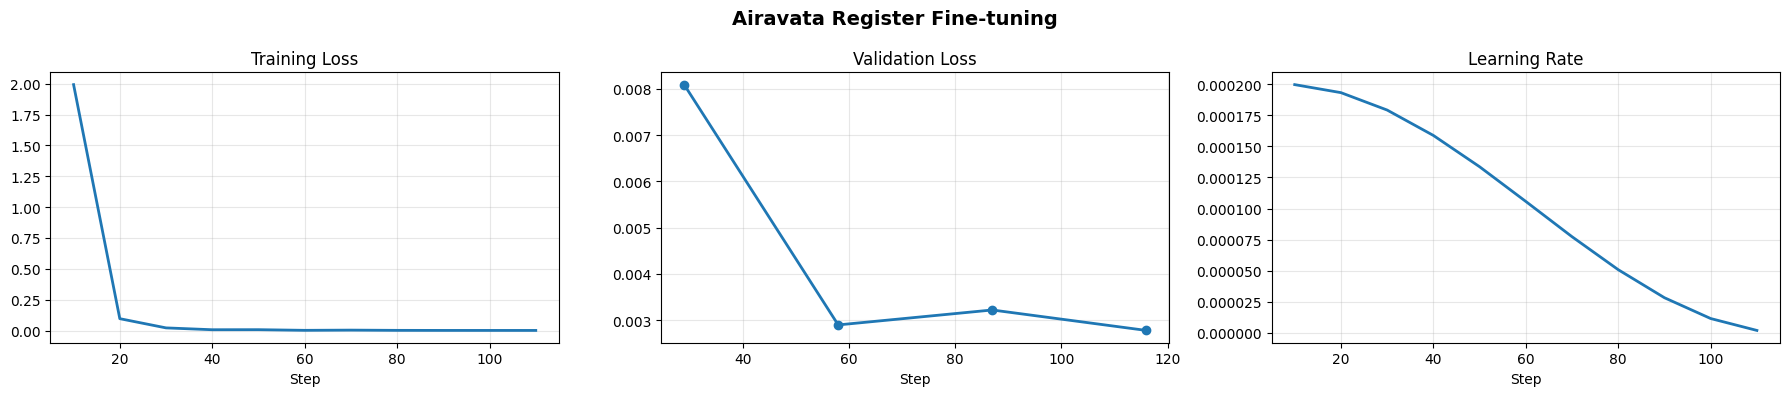

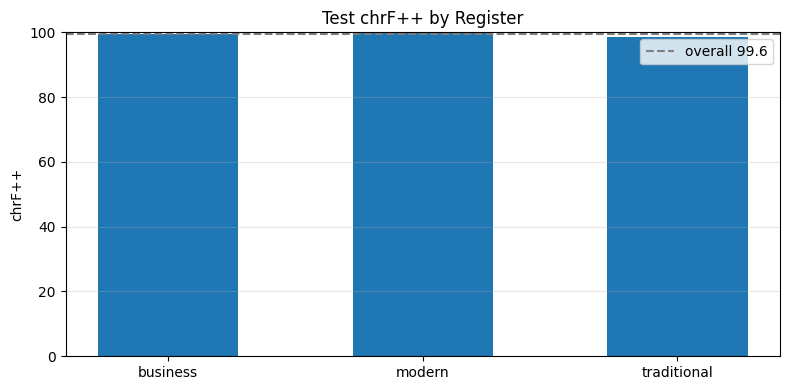

✓ Plots saved


In [13]:
# Cell 13: Training curves and register score plots
import matplotlib.pyplot as plt

state_paths = sorted(glob.glob(f"{CHECKPOINT_DIR}/checkpoint-*/trainer_state.json")) + [f"{CHECKPOINT_DIR}/trainer_state.json"]
state_path = next((p for p in state_paths if os.path.exists(p)), None)

if state_path:
    with open(state_path, "r", encoding="utf-8") as f:
        state = json.load(f)
    history = state.get("log_history", [])
    tr_steps, tr_loss, ev_steps, ev_loss, lr_steps, lrs = [], [], [], [], [], []
    for entry in history:
        step = entry.get("step", 0)
        if "loss" in entry:
            tr_steps.append(step); tr_loss.append(entry["loss"])
        if "eval_loss" in entry:
            ev_steps.append(step); ev_loss.append(entry["eval_loss"])
        if "learning_rate" in entry:
            lr_steps.append(step); lrs.append(entry["learning_rate"])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle("Airavata Register Fine-tuning", fontsize=14, fontweight="bold")
    axes[0].plot(tr_steps, tr_loss, lw=2)
    axes[0].set_title("Training Loss"); axes[0].set_xlabel("Step"); axes[0].grid(alpha=0.3)
    axes[1].plot(ev_steps, ev_loss, marker="o", lw=2)
    axes[1].set_title("Validation Loss"); axes[1].set_xlabel("Step"); axes[1].grid(alpha=0.3)
    axes[2].plot(lr_steps, lrs, lw=2)
    axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Step"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No trainer_state.json found; skipping loss curves.")

# Per-register test chart
reg_csv = f"{OUTPUT_DIR}/test_register_metrics.csv"
if os.path.exists(reg_csv):
    reg_df = pd.read_csv(reg_csv)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(reg_df["register"], reg_df["chrf++"], width=0.55)
    overall_df = pd.read_csv(f"{OUTPUT_DIR}/test_overall_metrics.csv")
    overall_score = float(overall_df.iloc[0]["chrf++"])
    ax.axhline(overall_score, linestyle="--", color="gray", label=f"overall {overall_score:.1f}")
    ax.set_title("Test chrF++ by Register")
    ax.set_ylim(0, 100)
    ax.set_ylabel("chrF++")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/test_register_chrf.png", dpi=150, bbox_inches="tight")
    plt.show()
print("✓ Plots saved")

In [14]:
# Cell 14: Inspect examples and exported artifacts
for split in ["val", "test"]:
    rows = read_jsonl(f"{PRED_DIR}/{split}_predictions.jsonl")
    print(f"\n{split.upper()} sample predictions")
    for row in rows[:5]:
        ok = "✓" if exact_match(row.get("prediction", ""), row.get("gold", "")) else "✗"
        score, compliant = row_term_score(row)
        print(f"[{ok}] register={row.get('register')} challenge={row.get('challenge_type')} term_ok={compliant}")
        print("SRC :", row.get("source", ""))
        print("TERM:", row.get("terminology_map", ""))
        print("GOLD:", row.get("gold", ""))
        print("PRED:", row.get("prediction", ""))
        print("-" * 80)

print("\nExported files")
for path in sorted(glob.glob(f"{OUTPUT_DIR}/**/*", recursive=True)):
    if os.path.isfile(path):
        print(path)


VAL sample predictions
[✓] register=modern challenge=3.2 term_ok=True
SRC : Rohan's business account was closed.
TERM: Account → अकाउंट
GOLD: Rohan का व्यापारिक अकाउंट बंद किया गया।
PRED: Rohan का व्यापारिक अकाउंट बंद किया गया।
--------------------------------------------------------------------------------
[✓] register=traditional challenge=3.3 term_ok=True
SRC : Give preference to structural loans over commercial ones.
TERM: Loans → ऋणों
GOLD: व्यावसायिक ऋणों की तुलना में स्ट्रक्चरल ऋणों को प्राथमिकता दें।
PRED: व्यावसायिक ऋणों की तुलना में स्ट्रक्चरल ऋणों को प्राथमिकता दें।
--------------------------------------------------------------------------------
[✓] register=modern challenge=3.1 term_ok=True
SRC : Check Ramesh's principal balance immediately.
TERM: Balance → बैलेंस
GOLD: तुरंत Ramesh का मूल बैलेंस जांचें।
PRED: तुरंत Ramesh का मूल बैलेंस जांचें।
--------------------------------------------------------------------------------
[✓] register=modern challenge=3.1 term_ok=True
SR